In [154]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gpt
import src.SHAP_like_graph_tool.ResidualDeterrenceEmbedding as gpk
#from src.SHAP_like_graph_tool.EmbeddingDecorele import *
#from src.LouvainDecorele import *

import networkx as nx
import numpy as np
import pandas as pd
import html
import io
import os
import json
import joblib
from scipy.spatial.distance import pdist, cdist
from scipy.stats import spearmanr
import multiprocessing
import time
from node2vec import Node2Vec
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Caca

In [155]:
def load_graphml_safe(path, startswith = False):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

def clean_graph_attributes(G, attributes_to_remove):
    attrs_set = set(attributes_to_remove)
    
    for node in G.nodes():
        node_attrs = G.nodes[node]
        existing_targets = attrs_set.intersection(node_attrs.keys())
        
        for attr in existing_targets:
            del node_attrs[attr] 
    return G

In [102]:
def load_graphml_safe(path, startswith = False):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return Gdef clean_graph_attributes(G, attributes_to_remove):
    """
    Supprime une liste d'attributs spécifiques de tous les nœuds d'un graphe NetworkX.
    Modifie le graphe en place.
    
    :param G: Graphe NetworkX (G_train, G, etc.)
    :param attributes_to_remove: Liste ou ensemble de chaînes (ex: ["ResDeterrEmbedd_sbm", "GT_pos"])
    """
    # On convertit en ensemble (set) pour une recherche en O(1) plus rapide
    attrs_set = set(attributes_to_remove)
    
    for node in G.nodes():
        # G.nodes[node] est le dictionnaire des attributs du nœud courant
        node_attrs = G.nodes[node]
        
        # On cherche l'intersection pour ne supprimer que ce qui existe vraiment
        existing_targets = attrs_set.intersection(node_attrs.keys())
        
        for attr in existing_targets:
            del node_attrs[attr]
            
    return G

In [156]:
def _append_node2vec_on_residu(G_train, R_matrix, nodes_list, p, q, attr_name, dimensions=2):
    """
    Génère des embeddings DeepWalk/Node2Vec sur la partie positive de la matrice de résidus (A - P).
    """
    print(f"Calcul de Node2Vec sur Résidus Positifs (p={p}, q={q}, dim={dimensions})...")
    start_skip = time.time()

    R_pos = np.maximum(0, R_matrix)
    np.fill_diagonal(R_pos, 0)

    G_residu = nx.Graph()
    G_residu.add_nodes_from(nodes_list)
    
    indices = np.argwhere(R_pos > 1e-5)
    edges_to_add = [
        (nodes_list[i], nodes_list[j], R_pos[i, j]) 
        for i, j in indices if i < j 
    ]
    G_residu.add_weighted_edges_from(edges_to_add)

    cores = multiprocessing.cpu_count() - 1
    
    node2vec = Node2Vec(G_residu, 
                        dimensions=dimensions, 
                        walk_length=30, 
                        num_walks=100, 
                        weight_key='weight', 
                        workers=cores, 
                        p=p, q=q)

    print("Entraînement du modèle Skip-gram...")
    try:
        model = node2vec.fit(window=10, min_count=1, batch_words=1000, vector_size=dimensions, workers=cores)
    except TypeError:
        model = node2vec.fit(window=10, min_count=1, batch_words=1000, size=dimensions, workers=cores)
    
    embeddings = {}
    for node in G_train.nodes():
        # Node2Vec convertit souvent en str en interne dans Word2Vec
        if str(node) in model.wv:
            embeddings[node] = model.wv[str(node)]
        elif node in model.wv:
            embeddings[node] = model.wv[node]
        else:
            # Sécurité si un nœud s'est retrouvé totalement isolé (degré résiduel = 0)
            embeddings[node] = np.zeros(dimensions)

    nx.set_node_attributes(G_train, embeddings, attr_name)

    end_skip = time.time()
    print(f"Skip-gram sur résidus terminé en {end_skip - start_skip:.2f}s")

In [157]:
def compute_local_topology_metrics(G, nodes_list, gt_coords, emb_coords, min_k=5, degree_multiplier=2):
    """
    Calcule le Trustworthiness et la Continuity avec un nombre de voisins (K)
    adaptatif par nœud, indexé sur son degré dans G.
    """
    n = len(nodes_list)
    
    # 1. Matrices de distances complètes (N x N)
    dist_gt = cdist(gt_coords, gt_coords, metric='euclidean')
    dist_emb = cdist(emb_coords, emb_coords, metric='euclidean')
    
    # On trie les indices des voisins du plus proche au plus lointain (le premier [:, 0] est le nœud lui-même)
    ranks_gt = np.argsort(dist_gt, axis=1)
    ranks_emb = np.argsort(dist_emb, axis=1)
    
    # Pour calculer rapidement les rangs inversés (utilisés pour le score de pénalité)
    # inverse_ranks_gt[i, j] donne le rang du nœud j dans le voisinage de i pour la GT
    inverse_ranks_gt = np.zeros_like(ranks_gt)
    inverse_ranks_emb = np.zeros_like(ranks_emb)
    for i in range(n):
        inverse_ranks_gt[i, ranks_gt[i]] = np.arange(n)
        inverse_ranks_emb[i, ranks_emb[i]] = np.arange(n)
        
    trust_node_scores = []
    cont_node_scores = []
    
    # 2. Boucle sur chaque nœud pour appliquer son K personnalisé
    for i, node in enumerate(nodes_list):
        deg = G.degree(node)
        k = max(min_k, degree_multiplier * deg)
        k = min(k, n - 2)  # Sécurité pour ne pas dépasser les dimensions du graphe
        
        # --- TRUSTWORTHINESS LOCAL ---
        # Voisins dans l'embedding (on exclut le nœud lui-même en commençant à 1)
        neighbors_emb = ranks_emb[i, 1:k+1]
        # Qui parmi eux n'est PAS un vrai voisin dans la GT ?
        # Un vrai voisin dans la GT est dans les rangs 1 à k
        penalty_trust = 0
        for j in neighbors_emb:
            r_gt = inverse_ranks_gt[i, j]
            if r_gt > k:  # Si son vrai rang géométrique est plus loin que K
                penalty_trust += (r_gt - k)
                
        # Normalisation théorique max pour ce nœud
        max_penalty = (n - k) * k
        trust_i = 1.0 - (penalty_trust / max_penalty) if max_penalty > 0 else 1.0
        trust_node_scores.append(trust_i)
        
        # --- CONTINUITY LOCAL ---
        # Voisins réels dans la GT
        neighbors_gt = ranks_gt[i, 1:k+1]
        # À quel point ont-ils été éparpillés dans l'embedding ?
        penalty_cont = 0
        for j in neighbors_gt:
            r_emb = inverse_ranks_emb[i, j]
            if r_emb > k:
                penalty_cont += (r_emb - k)
                
        cont_i = 1.0 - (penalty_cont / max_penalty) if max_penalty > 0 else 1.0
        cont_node_scores.append(cont_i)
        
    # On renvoie la moyenne sur tous les nœuds du graphe
    return np.mean(trust_node_scores), np.mean(cont_node_scores)

## 1.Calcul des métriques sur les graphes

In [159]:
emb_names = [
            #"SiNE_config", "spectr_no_decorel", "deepwalk",
            #"SiNE_decorel_pos", "spectr_decorel_pos", "deepwalk_decorel_pos",
            #"SiNE_decorel_sbm", "spectr_decorel_sbm", "deepwalk_decorel_sbm",
            "ResDeterrEmbedd_Config", "ResDeterrEmbedd_sbm", "ResDeterrEmbedd_pos", 
            ]

for sbm_ratio in np.arange(0.00, 1.10, 0.10):
    G_name = f"artificial_graph_sbmv_4_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    G_name_bis = f"artificial_graph_sbmv_4_embeds_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    
    # Charger le graphe d'origine
    G_train = joblib.load(f"outputs/results/embTests/{G_name_bis}.joblib")
    print(f"\n Graphe {G_name_bis} chargé.")

    # FIX CRUCIAL 1 : On extrait la VRAIE liste des nœuds de ce graphe chargé
    nodes_list = list(G_train.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes_list)}

    # Calcul des matrices de base alignées sur nodes_list
    A = nx.to_numpy_array(G_train, nodelist=nodes_list)
    degrees = np.sum(A, axis=1)
    m2 = np.sum(degrees)
    
    # Configuration Model Model Nul
    K = np.outer(degrees, degrees) / m2
    np.fill_diagonal(K, 0)
    
    # SBM Model Nul (Extraction propre de la matrice à l'index 0)
    nm_M_matrix, _ = gpk.assortative_gt_sbm_null_model(G_train, com_attr="GT_sbm_id")
    
    # Spatial Model Nul
    P, _ = gpt.get_gravity_null_model_manual_iterative(G_train, "GT_pos")

    # FIX CRUCIAL 2 : Fonctions d'appel basées sur le mapping exact de nodes_list
    def nm_K(u, v):
        return K[node_to_idx[u], node_to_idx[v]]

    def nm_P(u, v):
        return P[node_to_idx[u], node_to_idx[v]]
    
    # Lancement des optimisations (vérifie bien tes logs console ici !)
    print(" -> Optimisation Config...")
    gpk.append_residual_deterrence_embedding(G_train, null_model=nm_K, attr_name="ResDeterrEmbedd_Config_bis")
    print(" -> Optimisation SBM...")
    gpk.append_residual_deterrence_embedding(G_train, null_model=nm_M, attr_name="ResDeterrEmbedd_sbm_bis")
    print(" -> Optimisation Spatial...")
    gpk.append_residual_deterrence_embedding(G_train, null_model=nm_P, attr_name="ResDeterrEmbedd_pos_bis")

    #SiNE
    G_train = gpt._append_SiNEcustom(G_train, pos_attr=None, attr_name = "SiNE_config", NullModel_method = "ConfigModel", temperature=0.5, emb_dim=2)
    G_train = gpt._append_SiNEcustom(G_train, pos_attr="GT_pos", attr_name = "SiNE_decorel_pos", NullModel_method = "ManualIter", temperature=0.5, emb_dim=2)
    G_train = gpt._append_SiNEcustom(G_train, pos_attr="GT_sbm_id", attr_name = "SiNE_decorel_sbm", NullModel_method = "DC_sbm", temperature=0.5, emb_dim=2)

    #Spectres
    pos_spectral = nx.spectral_layout(G_train, dim=2, scale=1)
    embeddings_dict = {node: np.array(pos) for node, pos in pos_spectral.items()}
    nx.set_node_attributes(G_train, embeddings_dict, "spectr_no_decorel")

    A = nx.to_numpy_array(G_train, nodelist=nodes_list)
    P, _ = gpt.get_gravity_null_model_manual_iterative(G_train, "GT_pos")
    R = A - P
    X_embedding = gpt.compute_embedding_positive_only(R, 2)
    embeddings_dict = {node: X_embedding[i] for i, node in enumerate(nodes_list)}
    nx.set_node_attributes(G_train, embeddings_dict, "spectr_decorel_pos")

    partition_dict = {i: G_train.nodes[node]["GT_sbm_id"] for i, node in enumerate(nodes_list)}
    degrees = np.sum(A, axis=1)
    M = gp.compute_dc_sbm_matrix(A, degrees, partition_dict)
    R_sbm = A - M
    X_embedding = gpt.compute_embedding_positive_only(R_sbm, 2)
    embeddings_dict = {node: X_embedding[i] for i, node in enumerate(nodes_list)}
    nx.set_node_attributes(G_train, embeddings_dict, "spectr_decorel_sbm")

    #Node2vec
    gpt._append_node2vec_features(G_train, p=1, q=1, attr_name="deepwalk", dimensions=2)
    _append_node2vec_on_residu(G_train, R_matrix=R, nodes_list=nodes_list, 
                           p=1, q=1, attr_name="deepwalk_decorel_pos", dimensions=2)
    _append_node2vec_on_residu(G_train, R_matrix=R_sbm, nodes_list=nodes_list, 
                           p=1, q=1, attr_name="deepwalk_decorel_sbm", dimensions=2)
    
    
    # Sauvegarde du graphe écrasé avec ses nouveaux attributs optimisés
    joblib.dump(G_train, f"outputs/results/embTests/{G_name_bis}.joblib", compress=3)

print("\nFini !")


 Graphe artificial_graph_sbmv_4_embeds_0_00_pos_1_00_1 chargé.
Iteration 0: MAE = 1.316644, Beta = 0.8802
Modèle gravitaire inféré, avec une MAE de 0.009254689217525093, alpha moy = -1.0208 et beta = 0.020452594821109216
Vérification : Null Model donne P.sum / 2*nb_edges = 0.9999999999731429
 -> Optimisation Config...
restart 00 epoch 0001 objective=0.001927
restart 00 epoch 0100 objective=0.126199
restart 00 epoch 0200 objective=0.151077
restart 00 epoch 0300 objective=0.152928


KeyboardInterrupt: 

In [150]:
rows_list = []
emb_names = [
            #"SiNE_config", "spectr_no_decorel", "deepwalk",
            #"SiNE_decorel_pos", "spectr_decorel_pos", "deepwalk_decorel_pos",
            #"SiNE_decorel_sbm", "spectr_decorel_sbm", "deepwalk_decorel_sbm",
            #"ResDeterrEmbedd_Config", "ResDeterrEmbedd_sbm", "ResDeterrEmbedd_pos",
            "ResDeterrEmbedd_Config_bis", "ResDeterrEmbedd_sbm_bis", "ResDeterrEmbedd_pos_bis",
            ]

# On fait toute la boucle de 1.0 (Pur SBM) à 0.0 (Pur Spatial)
for sbm_ratio in np.arange(0.00, 1.10, 0.10):
    G_name = f"artificial_graph_sbmv_4_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    G_name_bis = f"artificial_graph_sbmv_4_embeds_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    path = f"graph_library/{G_name}.graphml"
    
    G_train = joblib.load(f"outputs/results/embTests/{G_name_bis}.joblib")

    # --- Extraction des distances paires-à-paires brutes ---
    gt_coords = np.array([G_train.nodes[n]['GT_pos'] for n in nodes_list])
    dist_gt = pdist(gt_coords, metric='euclidean')
    
    row_result = {"Ratio_SBM": round(sbm_ratio, 2)}
    
    for emb in emb_names:
        emb_coords = np.array([G_train.nodes[n][emb] for n in nodes_list])
        
        # CALCUL DES MÉTRIQUES LOCALES ADAPTATIVES
        trust, continuity = compute_local_topology_metrics(
            G_train, nodes_list, gt_coords, emb_coords, min_k=5, degree_multiplier=2
        )
        
        # Stockage dans le dictionnaire de résultats
        row_result[f"Trust_{emb}"] = trust
        row_result[f"Cont_{emb}"] = continuity
    
    rows_list.append(row_result)

df_results = pd.DataFrame(rows_list)
print("\n--- TABLEAU DES PERFORMANCES TOPOLOGIQUES LOCALES ---")
print(df_results.to_string(index=False))

output_dir = "outputs/results"
output_path = os.path.join(output_dir, "EmbedClosenessToGT_All_2_20260619.csv")
df_results.to_csv(output_path, index=False)
print(f"\n💾 Succès ! Le tableau a été sauvegardé dans : {output_path}")


--- TABLEAU DES PERFORMANCES TOPOLOGIQUES LOCALES ---
 Ratio_SBM  Trust_ResDeterrEmbedd_Config_bis  Cont_ResDeterrEmbedd_Config_bis  Trust_ResDeterrEmbedd_sbm_bis  Cont_ResDeterrEmbedd_sbm_bis  Trust_ResDeterrEmbedd_pos_bis  Cont_ResDeterrEmbedd_pos_bis
       0.0                          0.639386                         0.638612                       0.647785                      0.639059                       0.645529                      0.641590
       0.1                          0.644654                         0.641299                       0.650135                      0.635455                       0.643142                      0.640623
       0.2                          0.641133                         0.641755                       0.654187                      0.639621                       0.649380                      0.641357
       0.3                          0.643307                         0.641111                       0.649792                      0.636319       

💾 Graphique sauvegardé avec succès dans : outputs/plots/emb_decorel_RedDeterEmb_2_subplots_20260619.png


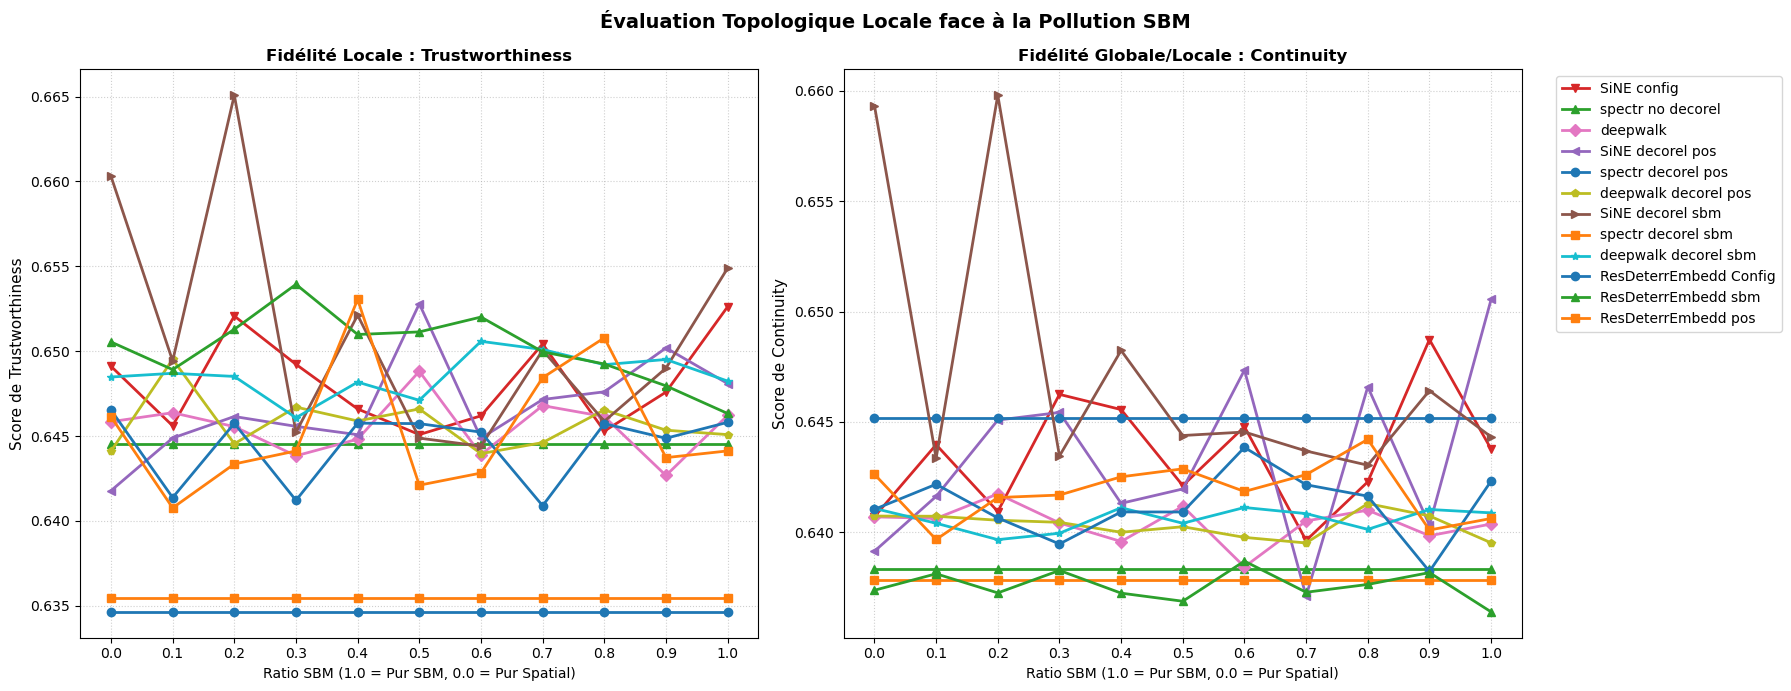

In [145]:
#df_results = pd.read_csv("outputs/results/EmbedClosenessToGT_RedDeterEmb_2_20260619.csv")
df_results = pd.read_csv("outputs/results/EmbedClosenessToGT_All_2_20260619.csv")
df_plot = df_results.sort_values(by="Ratio_SBM")

# 2. Détection dynamique des colonnes de métriques
trust_cols = [c for c in df_plot.columns if c.startswith("Trust_")]
cont_cols = [c for c in df_plot.columns if c.startswith("Cont_")]

# Génération automatique d'un dictionnaire de styles pour que le même modèle 
# ait la même couleur/marqueur sur les deux graphiques
all_models = sorted(list(set([c.replace("Trust_", "").replace("Cont_", "") for c in trust_cols + cont_cols])))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:olive', 'tab:cyan']
markers = ['o', 's', '^', 'v', '<', '>', 'D', 'p', '*']

model_styles = {
    model: {'color': colors[i % len(colors)], 'marker': markers[i % len(markers)]}
    for i, model in enumerate(all_models)
}

# 3. Initialisation des 2 subplots côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# --- GRAPH_1 : TRUSTWORTHINESS (À Gauche) ---
for col in trust_cols:
    model_name = col.replace("Trust_", "")
    style = model_styles[model_name]
    ax1.plot(df_plot["Ratio_SBM"], df_plot[col], 
             marker=style['marker'], linestyle='-', linewidth=2, color=style['color'],
             label=model_name.replace("_", " "))

ax1.set_title("Fidélité Locale : Trustworthiness", fontsize=12, fontweight='bold')
ax1.set_ylabel("Score de Trustworthiness", fontsize=11)
ax1.set_xlabel("Ratio SBM (1.0 = Pur SBM, 0.0 = Pur Spatial)", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.set_xticks(df_plot["Ratio_SBM"])

# --- GRAPH_2 : CONTINUITY (À Droite) ---
for col in cont_cols:
    model_name = col.replace("Cont_", "")
    style = model_styles[model_name]
    ax2.plot(df_plot["Ratio_SBM"], df_plot[col], 
             marker=style['marker'], linestyle='-', linewidth=2, color=style['color'],
             label=model_name.replace("_", " "))

ax2.set_title("Fidélité Globale/Locale : Continuity", fontsize=12, fontweight='bold')
ax2.set_ylabel("Score de Continuity", fontsize=11)
ax2.set_xlabel("Ratio SBM (1.0 = Pur SBM, 0.0 = Pur Spatial)", fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.6)

# --- Légende Unique et Habillage ---
# On met la légende tout à fait à droite en dehors des axes pour ne pas polluer les graphes
plt.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.04, 1.0))

fig.suptitle("Évaluation Topologique Locale face à la Pollution SBM", fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()

# Sauvegarde sécurisée
os.makedirs("outputs/plots", exist_ok=True)
output_plot_path = "outputs/plots/emb_decorel_RedDeterEmb_2_subplots_20260619.png"
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"💾 Graphique sauvegardé avec succès dans : {output_plot_path}")

plt.show()

In [154]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp
import src.SHAP_like_graph_tool.utils as gpt
import src.SHAP_like_graph_tool.ResidualDeterrenceEmbedding as gpk
#from src.SHAP_like_graph_tool.EmbeddingDecorele import *
#from src.LouvainDecorele import *

import networkx as nx
import numpy as np
import pandas as pd
import html
import io
import os
import json
import joblib
from scipy.spatial.distance import pdist, cdist
from scipy.stats import spearmanr
import multiprocessing
import time
from node2vec import Node2Vec
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Caca

In [155]:
def load_graphml_safe(path, startswith = False):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

def clean_graph_attributes(G, attributes_to_remove):
    attrs_set = set(attributes_to_remove)
    
    for node in G.nodes():
        node_attrs = G.nodes[node]
        existing_targets = attrs_set.intersection(node_attrs.keys())
        
        for attr in existing_targets:
            del node_attrs[attr] 
    return G

In [156]:
def _append_node2vec_on_residu(G_train, R_matrix, nodes_list, p, q, attr_name, dimensions=2):
    """
    Génère des embeddings DeepWalk/Node2Vec sur la partie positive de la matrice de résidus (A - P).
    """
    print(f"Calcul de Node2Vec sur Résidus Positifs (p={p}, q={q}, dim={dimensions})...")
    start_skip = time.time()

    R_pos = np.maximum(0, R_matrix)
    np.fill_diagonal(R_pos, 0)

    G_residu = nx.Graph()
    G_residu.add_nodes_from(nodes_list)
    
    indices = np.argwhere(R_pos > 1e-5)
    edges_to_add = [
        (nodes_list[i], nodes_list[j], R_pos[i, j]) 
        for i, j in indices if i < j 
    ]
    G_residu.add_weighted_edges_from(edges_to_add)

    cores = multiprocessing.cpu_count() - 1
    
    node2vec = Node2Vec(G_residu, 
                        dimensions=dimensions, 
                        walk_length=30, 
                        num_walks=100, 
                        weight_key='weight', 
                        workers=cores, 
                        p=p, q=q)

    print("Entraînement du modèle Skip-gram...")
    try:
        model = node2vec.fit(window=10, min_count=1, batch_words=1000, vector_size=dimensions, workers=cores)
    except TypeError:
        model = node2vec.fit(window=10, min_count=1, batch_words=1000, size=dimensions, workers=cores)
    
    embeddings = {}
    for node in G_train.nodes():
        # Node2Vec convertit souvent en str en interne dans Word2Vec
        if str(node) in model.wv:
            embeddings[node] = model.wv[str(node)]
        elif node in model.wv:
            embeddings[node] = model.wv[node]
        else:
            # Sécurité si un nœud s'est retrouvé totalement isolé (degré résiduel = 0)
            embeddings[node] = np.zeros(dimensions)

    nx.set_node_attributes(G_train, embeddings, attr_name)

    end_skip = time.time()
    print(f"Skip-gram sur résidus terminé en {end_skip - start_skip:.2f}s")

In [157]:
def compute_local_topology_metrics(G, nodes_list, gt_coords, emb_coords, min_k=5, degree_multiplier=2):
    """
    Calcule le Trustworthiness et la Continuity avec un nombre de voisins (K)
    adaptatif par nœud, indexé sur son degré dans G.
    """
    n = len(nodes_list)
    
    # 1. Matrices de distances complètes (N x N)
    dist_gt = cdist(gt_coords, gt_coords, metric='euclidean')
    dist_emb = cdist(emb_coords, emb_coords, metric='euclidean')
    
    # On trie les indices des voisins du plus proche au plus lointain (le premier [:, 0] est le nœud lui-même)
    ranks_gt = np.argsort(dist_gt, axis=1)
    ranks_emb = np.argsort(dist_emb, axis=1)
    
    # Pour calculer rapidement les rangs inversés (utilisés pour le score de pénalité)
    # inverse_ranks_gt[i, j] donne le rang du nœud j dans le voisinage de i pour la GT
    inverse_ranks_gt = np.zeros_like(ranks_gt)
    inverse_ranks_emb = np.zeros_like(ranks_emb)
    for i in range(n):
        inverse_ranks_gt[i, ranks_gt[i]] = np.arange(n)
        inverse_ranks_emb[i, ranks_emb[i]] = np.arange(n)
        
    trust_node_scores = []
    cont_node_scores = []
    
    # 2. Boucle sur chaque nœud pour appliquer son K personnalisé
    for i, node in enumerate(nodes_list):
        deg = G.degree(node)
        k = max(min_k, degree_multiplier * deg)
        k = min(k, n - 2)  # Sécurité pour ne pas dépasser les dimensions du graphe
        
        # --- TRUSTWORTHINESS LOCAL ---
        # Voisins dans l'embedding (on exclut le nœud lui-même en commençant à 1)
        neighbors_emb = ranks_emb[i, 1:k+1]
        # Qui parmi eux n'est PAS un vrai voisin dans la GT ?
        # Un vrai voisin dans la GT est dans les rangs 1 à k
        penalty_trust = 0
        for j in neighbors_emb:
            r_gt = inverse_ranks_gt[i, j]
            if r_gt > k:  # Si son vrai rang géométrique est plus loin que K
                penalty_trust += (r_gt - k)
                
        # Normalisation théorique max pour ce nœud
        max_penalty = (n - k) * k
        trust_i = 1.0 - (penalty_trust / max_penalty) if max_penalty > 0 else 1.0
        trust_node_scores.append(trust_i)
        
        # --- CONTINUITY LOCAL ---
        # Voisins réels dans la GT
        neighbors_gt = ranks_gt[i, 1:k+1]
        # À quel point ont-ils été éparpillés dans l'embedding ?
        penalty_cont = 0
        for j in neighbors_gt:
            r_emb = inverse_ranks_emb[i, j]
            if r_emb > k:
                penalty_cont += (r_emb - k)
                
        cont_i = 1.0 - (penalty_cont / max_penalty) if max_penalty > 0 else 1.0
        cont_node_scores.append(cont_i)
        
    # On renvoie la moyenne sur tous les nœuds du graphe
    return np.mean(trust_node_scores), np.mean(cont_node_scores)

## 1.Calcul des métriques sur les graphes

In [159]:
emb_names = [
            #"SiNE_config", "spectr_no_decorel", "deepwalk",
            #"SiNE_decorel_pos", "spectr_decorel_pos", "deepwalk_decorel_pos",
            #"SiNE_decorel_sbm", "spectr_decorel_sbm", "deepwalk_decorel_sbm",
            "ResDeterrEmbedd_Config", "ResDeterrEmbedd_sbm", "ResDeterrEmbedd_pos", 
            ]

for sbm_ratio in np.arange(0.00, 1.10, 0.10):
    G_name = f"artificial_graph_sbmv_4_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    G_name_bis = f"artificial_graph_sbmv_4_embeds_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    
    # Charger le graphe d'origine
    G_train = joblib.load(f"outputs/results/embTests/{G_name_bis}.joblib")
    print(f"\n Graphe {G_name_bis} chargé.")

    # FIX CRUCIAL 1 : On extrait la VRAIE liste des nœuds de ce graphe chargé
    nodes_list = list(G_train.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes_list)}

    # Calcul des matrices de base alignées sur nodes_list
    A = nx.to_numpy_array(G_train, nodelist=nodes_list)
    degrees = np.sum(A, axis=1)
    m2 = np.sum(degrees)
    
    # Configuration Model Model Nul
    K = np.outer(degrees, degrees) / m2
    np.fill_diagonal(K, 0)
    
    # SBM Model Nul (Extraction propre de la matrice à l'index 0)
    nm_M_matrix, _ = gpk.assortative_gt_sbm_null_model(G_train, com_attr="GT_sbm_id")
    
    # Spatial Model Nul
    P, _ = gpt.get_gravity_null_model_manual_iterative(G_train, "GT_pos")

    # FIX CRUCIAL 2 : Fonctions d'appel basées sur le mapping exact de nodes_list
    def nm_K(u, v):
        return K[node_to_idx[u], node_to_idx[v]]

    def nm_P(u, v):
        return P[node_to_idx[u], node_to_idx[v]]
    
    # Lancement des optimisations (vérifie bien tes logs console ici !)
    print(" -> Optimisation Config...")
    gpk.append_residual_deterrence_embedding(G_train, null_model=nm_K, attr_name="ResDeterrEmbedd_Config_bis")
    print(" -> Optimisation SBM...")
    gpk.append_residual_deterrence_embedding(G_train, null_model=nm_M, attr_name="ResDeterrEmbedd_sbm_bis")
    print(" -> Optimisation Spatial...")
    gpk.append_residual_deterrence_embedding(G_train, null_model=nm_P, attr_name="ResDeterrEmbedd_pos_bis")

    #SiNE
    G_train = gpt._append_SiNEcustom(G_train, pos_attr=None, attr_name = "SiNE_config", NullModel_method = "ConfigModel", temperature=0.5, emb_dim=2)
    G_train = gpt._append_SiNEcustom(G_train, pos_attr="GT_pos", attr_name = "SiNE_decorel_pos", NullModel_method = "ManualIter", temperature=0.5, emb_dim=2)
    G_train = gpt._append_SiNEcustom(G_train, pos_attr="GT_sbm_id", attr_name = "SiNE_decorel_sbm", NullModel_method = "DC_sbm", temperature=0.5, emb_dim=2)

    #Spectres
    pos_spectral = nx.spectral_layout(G_train, dim=2, scale=1)
    embeddings_dict = {node: np.array(pos) for node, pos in pos_spectral.items()}
    nx.set_node_attributes(G_train, embeddings_dict, "spectr_no_decorel")

    A = nx.to_numpy_array(G_train, nodelist=nodes_list)
    P, _ = gpt.get_gravity_null_model_manual_iterative(G_train, "GT_pos")
    R = A - P
    X_embedding = gpt.compute_embedding_positive_only(R, 2)
    embeddings_dict = {node: X_embedding[i] for i, node in enumerate(nodes_list)}
    nx.set_node_attributes(G_train, embeddings_dict, "spectr_decorel_pos")

    partition_dict = {i: G_train.nodes[node]["GT_sbm_id"] for i, node in enumerate(nodes_list)}
    degrees = np.sum(A, axis=1)
    M = gp.compute_dc_sbm_matrix(A, degrees, partition_dict)
    R_sbm = A - M
    X_embedding = gpt.compute_embedding_positive_only(R_sbm, 2)
    embeddings_dict = {node: X_embedding[i] for i, node in enumerate(nodes_list)}
    nx.set_node_attributes(G_train, embeddings_dict, "spectr_decorel_sbm")

    #Node2vec
    gpt._append_node2vec_features(G_train, p=1, q=1, attr_name="deepwalk", dimensions=2)
    _append_node2vec_on_residu(G_train, R_matrix=R, nodes_list=nodes_list, 
                           p=1, q=1, attr_name="deepwalk_decorel_pos", dimensions=2)
    _append_node2vec_on_residu(G_train, R_matrix=R_sbm, nodes_list=nodes_list, 
                           p=1, q=1, attr_name="deepwalk_decorel_sbm", dimensions=2)
    
    
    # Sauvegarde du graphe écrasé avec ses nouveaux attributs optimisés
    joblib.dump(G_train, f"outputs/results/embTests/{G_name_bis}.joblib", compress=3)

print("\nFini !")


 Graphe artificial_graph_sbmv_4_embeds_0_00_pos_1_00_1 chargé.
Iteration 0: MAE = 1.316644, Beta = 0.8802
Modèle gravitaire inféré, avec une MAE de 0.009254689217525093, alpha moy = -1.0208 et beta = 0.020452594821109216
Vérification : Null Model donne P.sum / 2*nb_edges = 0.9999999999731429
 -> Optimisation Config...
restart 00 epoch 0001 objective=0.001927
restart 00 epoch 0100 objective=0.126199
restart 00 epoch 0200 objective=0.151077
restart 00 epoch 0300 objective=0.152928


KeyboardInterrupt: 

In [150]:
rows_list = []
emb_names = [
            #"SiNE_config", "spectr_no_decorel", "deepwalk",
            #"SiNE_decorel_pos", "spectr_decorel_pos", "deepwalk_decorel_pos",
            #"SiNE_decorel_sbm", "spectr_decorel_sbm", "deepwalk_decorel_sbm",
            #"ResDeterrEmbedd_Config", "ResDeterrEmbedd_sbm", "ResDeterrEmbedd_pos",
            "ResDeterrEmbedd_Config_bis", "ResDeterrEmbedd_sbm_bis", "ResDeterrEmbedd_pos_bis",
            ]

# On fait toute la boucle de 1.0 (Pur SBM) à 0.0 (Pur Spatial)
for sbm_ratio in np.arange(0.00, 1.10, 0.10):
    G_name = f"artificial_graph_sbmv_4_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    G_name_bis = f"artificial_graph_sbmv_4_embeds_{sbm_ratio:.2f}_pos_{1-sbm_ratio:.2f}_{nbiter}".replace('.', '_')
    path = f"graph_library/{G_name}.graphml"
    
    G_train = joblib.load(f"outputs/results/embTests/{G_name_bis}.joblib")

    # --- Extraction des distances paires-à-paires brutes ---
    gt_coords = np.array([G_train.nodes[n]['GT_pos'] for n in nodes_list])
    dist_gt = pdist(gt_coords, metric='euclidean')
    
    row_result = {"Ratio_SBM": round(sbm_ratio, 2)}
    
    for emb in emb_names:
        emb_coords = np.array([G_train.nodes[n][emb] for n in nodes_list])
        
        # CALCUL DES MÉTRIQUES LOCALES ADAPTATIVES
        trust, continuity = compute_local_topology_metrics(
            G_train, nodes_list, gt_coords, emb_coords, min_k=5, degree_multiplier=2
        )
        
        # Stockage dans le dictionnaire de résultats
        row_result[f"Trust_{emb}"] = trust
        row_result[f"Cont_{emb}"] = continuity
    
    rows_list.append(row_result)

df_results = pd.DataFrame(rows_list)
print("\n--- TABLEAU DES PERFORMANCES TOPOLOGIQUES LOCALES ---")
print(df_results.to_string(index=False))

output_dir = "outputs/results"
output_path = os.path.join(output_dir, "EmbedClosenessToGT_All_2_20260619.csv")
df_results.to_csv(output_path, index=False)
print(f"\n💾 Succès ! Le tableau a été sauvegardé dans : {output_path}")


--- TABLEAU DES PERFORMANCES TOPOLOGIQUES LOCALES ---
 Ratio_SBM  Trust_ResDeterrEmbedd_Config_bis  Cont_ResDeterrEmbedd_Config_bis  Trust_ResDeterrEmbedd_sbm_bis  Cont_ResDeterrEmbedd_sbm_bis  Trust_ResDeterrEmbedd_pos_bis  Cont_ResDeterrEmbedd_pos_bis
       0.0                          0.639386                         0.638612                       0.647785                      0.639059                       0.645529                      0.641590
       0.1                          0.644654                         0.641299                       0.650135                      0.635455                       0.643142                      0.640623
       0.2                          0.641133                         0.641755                       0.654187                      0.639621                       0.649380                      0.641357
       0.3                          0.643307                         0.641111                       0.649792                      0.636319       

💾 Graphique sauvegardé avec succès dans : outputs/plots/emb_decorel_RedDeterEmb_2_subplots_20260619.png


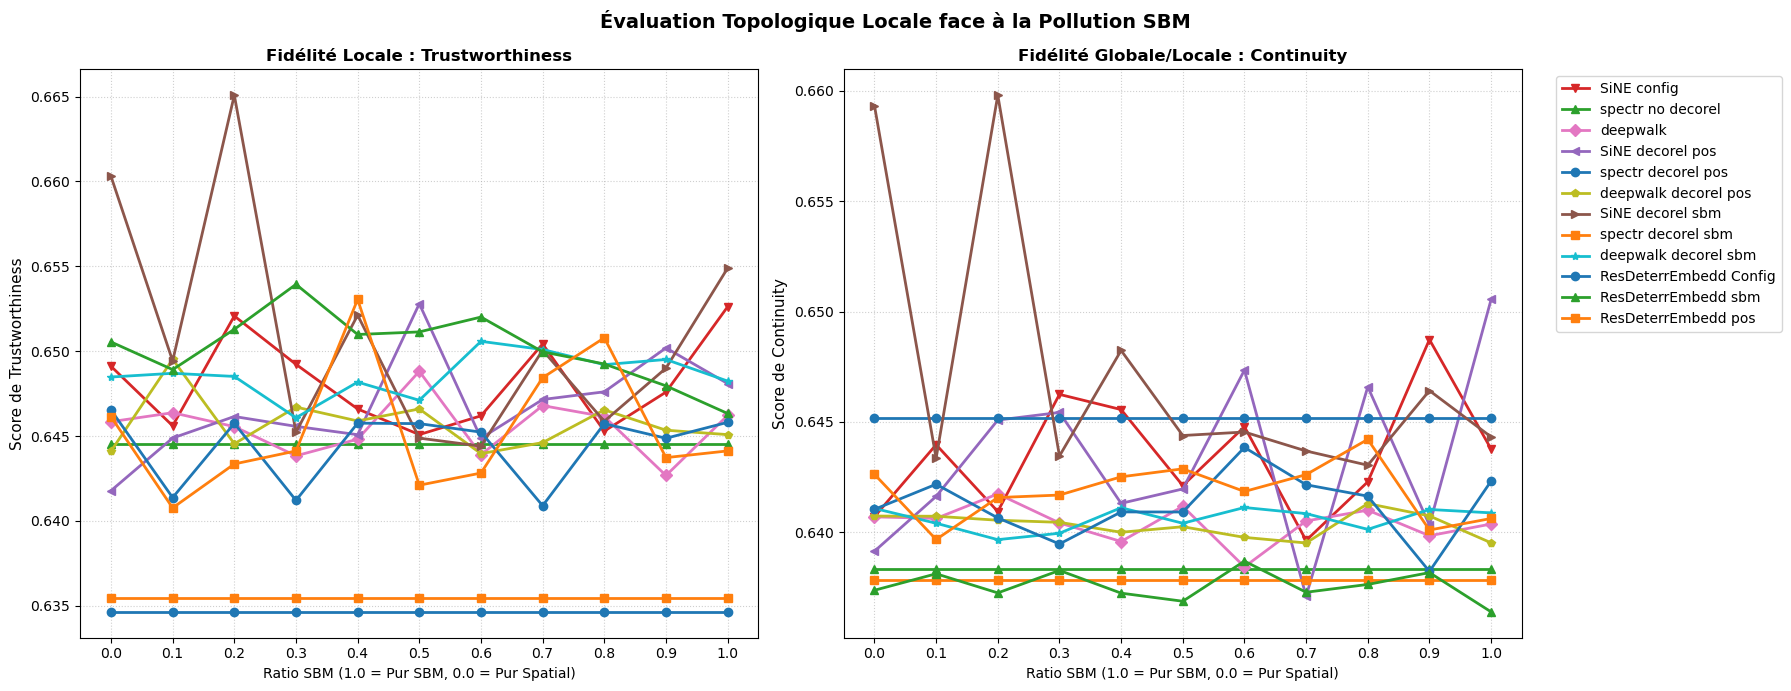

In [145]:
#df_results = pd.read_csv("outputs/results/EmbedClosenessToGT_RedDeterEmb_2_20260619.csv")
df_results = pd.read_csv("outputs/results/EmbedClosenessToGT_All_2_20260619.csv")
df_plot = df_results.sort_values(by="Ratio_SBM")

# 2. Détection dynamique des colonnes de métriques
trust_cols = [c for c in df_plot.columns if c.startswith("Trust_")]
cont_cols = [c for c in df_plot.columns if c.startswith("Cont_")]

# Génération automatique d'un dictionnaire de styles pour que le même modèle 
# ait la même couleur/marqueur sur les deux graphiques
all_models = sorted(list(set([c.replace("Trust_", "").replace("Cont_", "") for c in trust_cols + cont_cols])))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:olive', 'tab:cyan']
markers = ['o', 's', '^', 'v', '<', '>', 'D', 'p', '*']

model_styles = {
    model: {'color': colors[i % len(colors)], 'marker': markers[i % len(markers)]}
    for i, model in enumerate(all_models)
}

# 3. Initialisation des 2 subplots côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# --- GRAPH_1 : TRUSTWORTHINESS (À Gauche) ---
for col in trust_cols:
    model_name = col.replace("Trust_", "")
    style = model_styles[model_name]
    ax1.plot(df_plot["Ratio_SBM"], df_plot[col], 
             marker=style['marker'], linestyle='-', linewidth=2, color=style['color'],
             label=model_name.replace("_", " "))

ax1.set_title("Fidélité Locale : Trustworthiness", fontsize=12, fontweight='bold')
ax1.set_ylabel("Score de Trustworthiness", fontsize=11)
ax1.set_xlabel("Ratio SBM (1.0 = Pur SBM, 0.0 = Pur Spatial)", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.set_xticks(df_plot["Ratio_SBM"])

# --- GRAPH_2 : CONTINUITY (À Droite) ---
for col in cont_cols:
    model_name = col.replace("Cont_", "")
    style = model_styles[model_name]
    ax2.plot(df_plot["Ratio_SBM"], df_plot[col], 
             marker=style['marker'], linestyle='-', linewidth=2, color=style['color'],
             label=model_name.replace("_", " "))

ax2.set_title("Fidélité Globale/Locale : Continuity", fontsize=12, fontweight='bold')
ax2.set_ylabel("Score de Continuity", fontsize=11)
ax2.set_xlabel("Ratio SBM (1.0 = Pur SBM, 0.0 = Pur Spatial)", fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.6)

# --- Légende Unique et Habillage ---
# On met la légende tout à fait à droite en dehors des axes pour ne pas polluer les graphes
plt.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.04, 1.0))

fig.suptitle("Évaluation Topologique Locale face à la Pollution SBM", fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()

# Sauvegarde sécurisée
os.makedirs("outputs/plots", exist_ok=True)
output_plot_path = "outputs/plots/emb_decorel_RedDeterEmb_2_subplots_20260619.png"
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"💾 Graphique sauvegardé avec succès dans : {output_plot_path}")

plt.show()